# Project: Exoplanet Data Analysis
## Author: Jef Hinton
## Date: 1/10/2025
## Geol 558

"""
### Exoplanet Data Analysis

In this notebook, we will:
1. **Import the Data**: Load the dataset for analysis.
2. **Clean the Data**: Handle missing values, duplicates, and ensure the data is in a usable format.
3. **Data Exploration**: Perform exploratory data analysis (EDA) to understand the relationships between variables.

### Objective:
The goal is to gain insights on exoplanets and their host stars by analyzing key features such as planet radius, orbital period, stellar radius and eventually seeing if these clusters are similar or different to other confirmed exoplanets.


### Step 1: Import the Data

In this step, we will load the exoplanet dataset into our environment.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [44]:
from google.colab import drive
drive.mount('/content/drive')

# Load dataset


# skipping 90 rows because fun header information at the top
df = pd.read_csv("/content/drive/MyDrive/A_unsupervised_exoplanet/TESS_project_candidates.csv", skiprows=90)

confirmed_exoplanets_df = pd.read_csv("/content/drive/MyDrive/A_unsupervised_exoplanet/Confirmed_planets.csv", skiprows=291)

# List of columns to drop Alot of these are error and units for the TESS candidates dataset
columns_to_drop = [
    'rowid', 'tid', 'pl_pnum', 'ctoi_alias', 'toi_created', 'rowupdate',
    'rastr', 'ra', 'decstr', 'dec', 'decerr1', 'decerr2',
    'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmrasymerr',
    'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'st_pmdecsymerr',
    'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_tranmidsymerr',
    'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbpersymerr',
    'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandurhsymerr',
    'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_trandepsymerr',
    'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radesymerr',
    'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_insolsymerr',
    'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'pl_eqtsymerr',
    'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_tmagsymerr',
    'st_disterr1', 'st_disterr2', 'st_distlim', 'st_distsymerr',
    'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_teffsymerr',
    'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_loggsymerr',
    'st_raderr1', 'st_raderr2', 'st_radlim', 'st_radsymerr','raerr1', 'raerr2',
]

columns_to_drop_confirmed = ['rowid', 'rowupdate', 'rastr', 'ra', 'decstr',
                            'dec', 'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2',
                            'pl_tranmidlim', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim',
                            'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim',
                            'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_insolerr1',
                            'pl_insolerr2','pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tefferr1',
                            'st_tefferr2', 'st_tefflim', 'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_raderr1',
                            'st_raderr2', 'st_radlim']

'''
# columns kept for analysis

  pl_orbper: Orbital period (important for planet characteristics).
  pl_rade: Planet radius.
  pl_insol: Planetary insolation (important for habitability studies).
  pl_eqt: Equilibrium temperature.
  st_dist: Stellar distance (important for understanding the environment of the planets).
  st_teff: Stellar effective temperature.
  st_logg: Stellar log surface gravity.
  st_rad: Stellar radius.
    '''

# Drop the unnecessary columns
df_cleaned = df.drop(columns=columns_to_drop)
confirmed_exoplanets_df_cleaned = confirmed_exoplanets_df.drop(columns=columns_to_drop_confirmed)

confirmed_exoplanets_df = confirmed_exoplanets_df_cleaned
df = df_cleaned

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
confirmed_exoplanets_df.to_csv('confirmed_exoplanets_clean.csv', index=False)

### Step 2: Dataset Description

The data includes the following columns:

- **toi**: The TESS Object of Interest identifier.
- **toipfx**: A TESS planet candidate identifier.
- **pl_orbper**: The orbital period of the exoplanet.
- **pl_rade**: The radius of the exoplanet.
- **pl_insol**: The insolation (energy received by the planet) value of the exoplanet.
- **st_tmag**: The apparent magnitude of the host star.
- **st_dist**: The distance of the host star from Earth.
- **st_teff**: The effective temperature of the host star.
- **st_logg**: The logarithmic surface gravity of the host star.
- **st_rad**: The radius of the host star.

I'll describe the dataset, and show the shape and columns that will be under analysis


In [17]:
df.describe()


,toi,toipfx,pl_orbper,pl_rade,pl_insol,st_tmag,st_dist,st_teff,st_logg,st_rad
count,7358.000000,7358.000000,7256.000000,6874.000000,7202.000000,7358.000000,7147.000000,7214.000000,6542.000000,6874.000000
mean,3585.072736,3585.062245,17.993210,10.324896,2254.521765,11.527877,475.692040,5798.666507,4.305184,1.407948
std,2055.197058,2055.197409,98.481552,8.655134,10719.704497,1.637732,566.010695,1500.071273,0.305602,1.629440
min,101.010000,101.000000,0.152076,0.552507,0.000342,4.627800,6.531270,2808.000000,0.100000,0.114827
25%,1788.260000,1788.250000,2.460728,4.399826,85.967076,10.359500,176.400500,5205.850000,4.123918,0.890000
50%,3567.510000,3567.500000,4.078383,10.504180,365.852081,11.781250,360.072000,5801.500000,4.330000,1.240000
75%,5372.760000,5372.750000,7.906320,14.045700,1174.535000,12.837675,642.938000,6303.650000,4.500000,1.660810
max,7175.010000,7175.000000,1837.889731,297.111726,280833.000000,18.332400,14728.300000,50000.000000,5.960650,102.030000


In [18]:
confirmed_exoplanets_df.describe()

,default_flag,sy_snum,sy_pnum,sy_mnum,cb_flag,disc_year,rv_flag,pul_flag,ptv_flag,tran_flag,...,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
count,5037.000000,5037.000000,5037.000000,5037.0,5037.000000,5037.000000,5037.000000,5037.0,5037.0,5037.000000,...,1522.000000,0.0,0.0,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000
mean,0.325392,1.192376,1.745682,0.0,0.002978,2013.167163,0.804249,0.0,0.0,0.561842,...,11.897927,NaN,NaN,0.920572,1.615568,1.012510,0.777204,0.292097,0.623908,0.018666
std,0.468568,0.458047,1.161606,0.0,0.054495,6.457708,0.396817,0.0,0.0,0.496210,...,1.862214,NaN,NaN,1.363172,6.295941,1.906254,1.947372,1.678376,3.173490,0.292999
min,0.000000,1.000000,1.000000,0.0,0.000000,1995.000000,0.000000,0.0,0.0,0.000000,...,5.973000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.0,0.000000,2009.000000,1.000000,0.0,0.0,0.000000,...,10.811000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.0,0.000000,2015.000000,1.000000,0.0,0.0,1.000000,...,12.188000,NaN,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,2.000000,0.0,0.000000,2018.000000,1.000000,0.0,0.0,1.000000,...,13.033750,NaN,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,4.000000,6.000000,0.0,1.000000,2025.000000,1.000000,0.0,0.0,1.000000,...,16.061000,NaN,NaN,10.000000,60.000000,11.000000,13.000000,19.000000,32.000000,6.000000


In [19]:
print(list(confirmed_exoplanets_df.columns))

['pl_name', 'hostname', 'pl_letter', 'hd_name', 'hip_name', 'tic_id', 'gaia_id', 'default_flag', 'sy_snum', 'sy_pnum', 'sy_mnum', 'cb_flag', 'discoverymethod', 'disc_year', 'disc_refname', 'disc_pubdate', 'disc_locale', 'disc_facility', 'disc_telescope', 'disc_instrument', 'rv_flag', 'pul_flag', 'ptv_flag', 'tran_flag', 'ast_flag', 'obm_flag', 'micro_flag', 'etv_flag', 'ima_flag', 'dkin_flag', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_masse', 'pl_masseerr1', 'pl_masseerr2', 'pl_masselim', 'pl_massj', 'pl_massjerr1', 'pl_massjerr2', 'pl_massjlim', 'pl_msinie', 'pl_msinieerr1', 'pl_msinieerr2', 'pl_msinielim', 'pl_msinij', 'pl_msinijerr1', 'pl_msinijerr2', 'pl_msinijlim', 'pl_cmasse', 'pl_cmasseerr1', 'pl_cmasseerr2', 'pl_cmasselim', 'pl_cmassj', 'pl_cmassjerr1', 'pl_cmassjerr2', 'pl_cmassjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr

In [20]:
# This is a helper function to find the columns we dropped from the TESS project candidates and remove from the confirmed exoplanets.
# if the list is blank that means we removed all the same columns from both DFS

def find_overlap(list_a, list_b):
  """
  Finds the overlap between two lists.

  Args:
    list_a: The first list.
    list_b: The second list.

  Returns:
    A new list containing only the elements that are in both list_a and list_b.
  """

  overlap = []  # Initialize an empty list to store the overlapping elements
  for element in list_a:
    if element in list_b:  # Check if the element is also present in list_b
      overlap.append(element)  # If yes, add it to the overlap list

  return overlap  # Return the overlap list

  columns_to_drop = [
    'rowid', 'tid', 'pl_pnum', 'ctoi_alias', 'toi_created', 'rowupdate',
    'rastr', 'ra', 'decstr', 'dec', 'decerr1', 'decerr2',
    'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmrasymerr',
    'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'st_pmdecsymerr',
    'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_tranmidsymerr',
    'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbpersymerr',
    'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandurhsymerr',
    'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_trandepsymerr',
    'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radesymerr',
    'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_insolsymerr',
    'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'pl_eqtsymerr',
    'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_tmagsymerr',
    'st_disterr1', 'st_disterr2', 'st_distlim', 'st_distsymerr',
    'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_teffsymerr',
    'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_loggsymerr',
    'st_raderr1', 'st_raderr2', 'st_radlim', 'st_radsymerr','raerr1', 'raerr2',
]

print(find_overlap(columns_to_drop, list(confirmed_exoplanets_df.columns)))




[]


In [24]:
print("Df info for TESS project candidates ")
print("Shape of the dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Df info for TESS project candidates 
Shape of the dataset: (7358, 11)
Number of rows: 7358
Number of columns: 11


In [25]:
print("Df info for Confirmed exoplanets ")
print("Shape of the dataset:", confirmed_exoplanets_df.shape)
print("Number of rows:", confirmed_exoplanets_df.shape[0])
print("Number of columns:", confirmed_exoplanets_df.shape[1])

Df info for Confirmed exoplanets 
Shape of the dataset: (5037, 252)
Number of rows: 5037
Number of columns: 252


In [26]:
print(" TESS Candidates Summary statistics of numerical columns:")
print(df.describe())

 TESS Candidates Summary statistics of numerical columns:
               toi       toipfx    pl_orbper      pl_rade       pl_insol  \
count  7358.000000  7358.000000  7256.000000  6874.000000    7202.000000   
mean   3585.072736  3585.062245    17.993210    10.324896    2254.521765   
std    2055.197058  2055.197409    98.481552     8.655134   10719.704497   
min     101.010000   101.000000     0.152076     0.552507       0.000342   
25%    1788.260000  1788.250000     2.460728     4.399826      85.967076   
50%    3567.510000  3567.500000     4.078383    10.504180     365.852081   
75%    5372.760000  5372.750000     7.906320    14.045700    1174.535000   
max    7175.010000  7175.000000  1837.889731   297.111726  280833.000000   

           st_tmag       st_dist       st_teff      st_logg       st_rad  
count  7358.000000   7147.000000   7214.000000  6542.000000  6874.000000  
mean     11.527877    475.692040   5798.666507     4.305184     1.407948  
std       1.637732    566.010695

### Step 3: Data Exploration and Visualization

1. **Missing Data Heatmap**: visually displays the locations and patterns of missing values within a dataset.
2. **Seaborn Pair Plot**: The pair plot will allow us to examine the pairwise relationships between the variables in the dataset.

3. **Correlation Matrix**: shows strength and direction of relationships between variables.

4. **Cumulative Distribution Function (CDF)**: The CDF will help us visualize the distribution of individual variables.


In [27]:
print("Missing data in each column:")
print(df.isnull().sum())


Missing data in each column:
toi              0
toipfx           0
tfopwg_disp      2
pl_orbper      102
pl_rade        484
pl_insol       156
st_tmag          0
st_dist        211
st_teff        144
st_logg        816
st_rad         484
dtype: int64


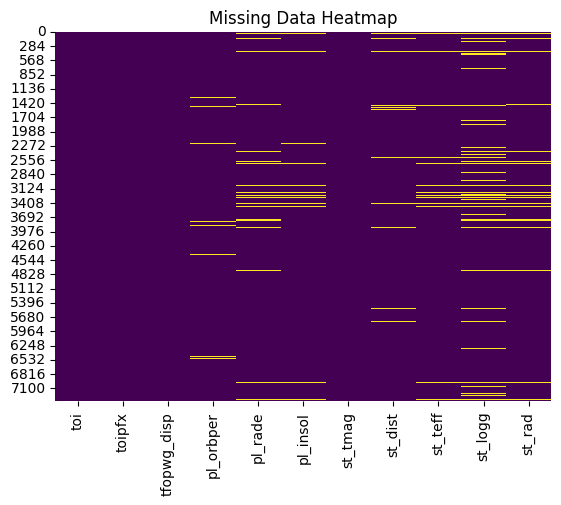

In [28]:
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

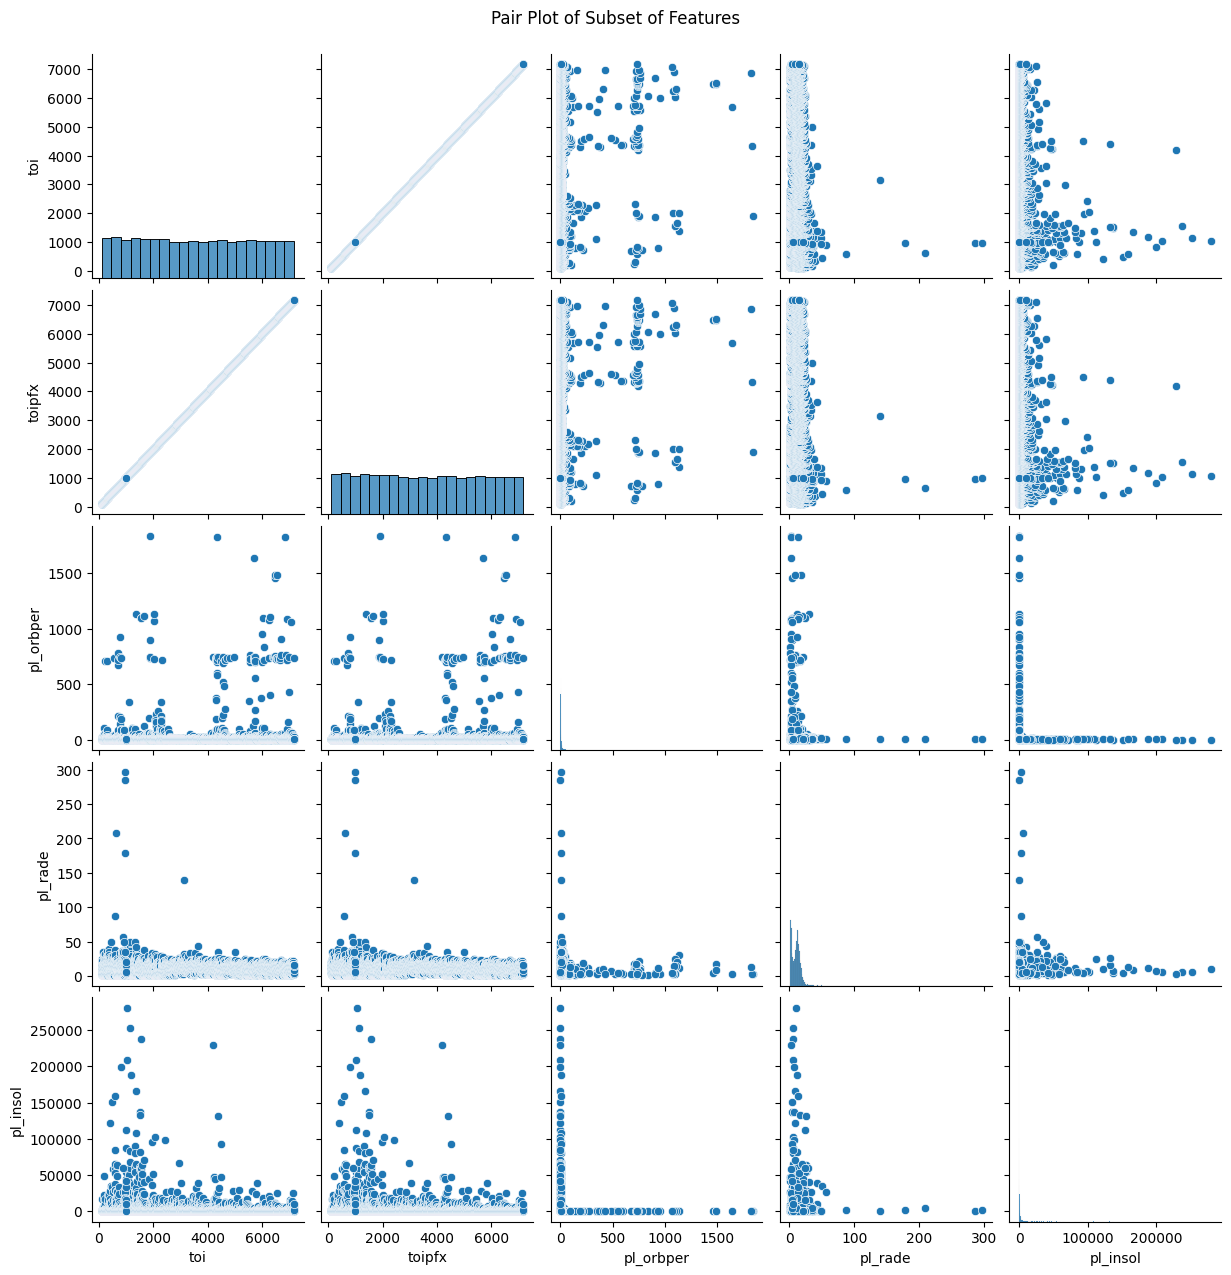

In [29]:
# Select a subset of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns[:5]  # Select first 5 numerical columns
sns.pairplot(df[numerical_cols])
plt.suptitle("Pair Plot of Subset of Features", y=1.02)
plt.show()

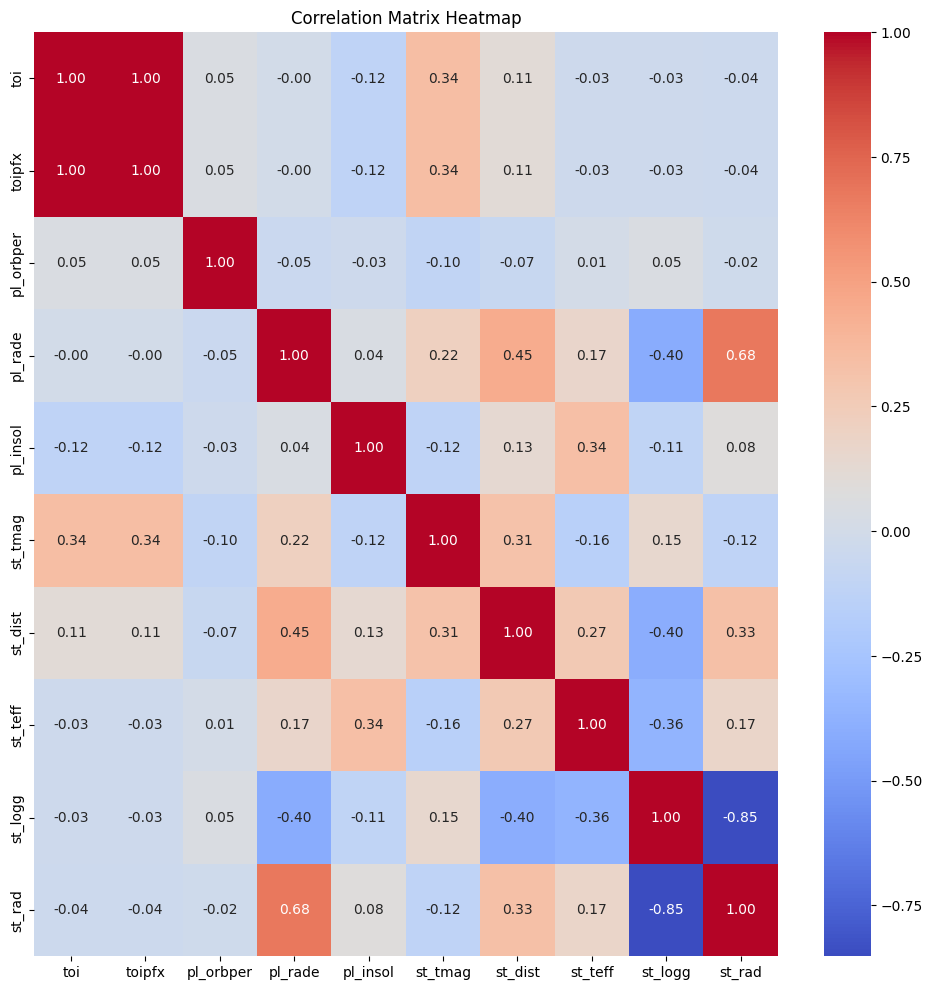

In [30]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number)

# Calculate correlation matrix for numerical columns
corr_matrix = numerical_cols.corr()

# Plot the heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


This makes me think TOI and TOIPFX are the same because they're corellation is 1.0 and we could remove one of these.

In [33]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number)

# Calculate correlation matrix for numerical columns
corr_matrix = numerical_cols.corr()

# Save the correlation matrix to a CSV file
corr_matrix.to_csv("correlation_matrix.csv")

# print it to the console as comma-separated values
print(corr_matrix.to_csv())

,toi,toipfx,pl_orbper,pl_rade,pl_insol,st_tmag,st_dist,st_teff,st_logg,st_rad
toi,1.0,0.9999999999991604,0.05063538359266598,-0.0018858009713649084,-0.1170262022038125,0.3444808407854958,0.1060947641212971,-0.033193040650104005,-0.028039857736739716,-0.04097845519182321
toipfx,0.9999999999991604,1.0,0.050635320932657754,-0.0018855833577654754,-0.11702613452090296,0.34448098362627927,0.10609489927950566,-0.03319293242348405,-0.02804005389062437,-0.040978361343543455
pl_orbper,0.05063538359266598,0.050635320932657754,1.0,-0.0502774487877117,-0.0341403807429329,-0.10483900802721308,-0.06847613298383823,0.0074600974417635925,0.04877970014335844,-0.024762459680037728
pl_rade,-0.0018858009713649084,-0.0018855833577654754,-0.0502774487877117,1.0,0.03884667799942535,0.21845118511558098,0.4462523258769556,0.1658400404726298,-0.4048870491966356,0.6779944021245355
pl_insol,-0.1170262022038125,-0.11702613452090296,-0.0341403807429329,0.03884667799942535,1.0,-0.11707169824645612,0.13259835670566134

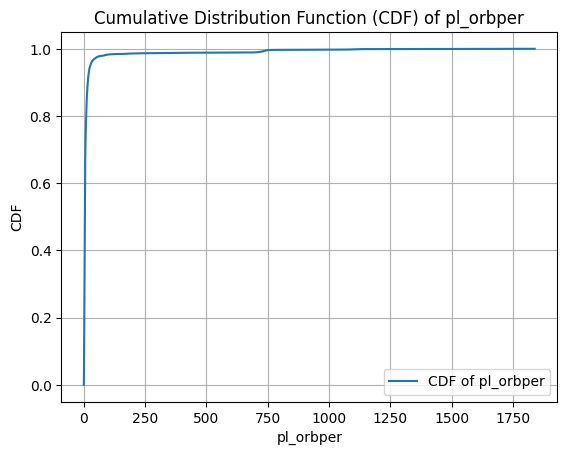

In [34]:
# Select the column for which we want to plot the CDF
data_column = 'pl_orbper'

# Sort the data in ascending order and compute the cumulative probability
sorted_data = np.sort(df[data_column].dropna())
cdf = np.arange(len(sorted_data)) / len(sorted_data)

# Plot the CDF
plt.plot(sorted_data, cdf, label=f'CDF of {data_column}')
plt.xlabel(data_column)
plt.ylabel("CDF")
plt.title(f"Cumulative Distribution Function (CDF) of {data_column}")
plt.legend()
plt.grid()
plt.show()


Looks like data may be skewed to the right for pl_orbper